<a href="https://colab.research.google.com/github/AritraDasIT/Analog_clock/blob/main/phishing3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Training Dataset.arff to Training Dataset.arff


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB





In [ ]:
from scipy.io import arff

# Load ARFF dataset
data, meta = arff.loadarff('/content/Training Dataset.arff')
df = pd.DataFrame(data)


# Check if ANY missing value exists
missing_values = df.isnull().sum()
print(missing_values)
print(df.isnull().values.any())

print(df.duplicated().sum()) # Check if  duplicate value exists
df = df.drop_duplicates()    # remove duplicate values
print("Duplicates after removal:", df.duplicated().sum())

print(df.columns)            # See all column names
label_col = df.columns[-1]   # selects the last column

print(df[label_col].value_counts())  # show class distribution

df.dtypes





# converts every value in the DataFrame to an integer
df = df.applymap(lambda x: int(x))
df.dtypes


print("Dataset shape:", df.shape)


# 2. Split features and target
X = df.iloc[:, :-1]                # X contains Input features only  (website features)
y = df.iloc[:, -1]                 # Y Cintains output labels

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Feature shape:", X.shape)







having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

/tmp/ipykernel_2770/3346574723.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x))


In [ ]:
#Random forest

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)       # performs hyperparameter tuning using cross-validation.
best_rf = grid_search.best_estimator_   #  returns the model with the best parameter combination found during the search.

print("Best Parameters Found:")
print(grid_search.best_params_)
rf_pred = best_rf.predict(X_test)

print("Optimized Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nOptimized Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)    #  # Uses the best trained Random Forest model to make predictions on the test data.

sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.ylabel("Actual")
plt.show()



Best Parameters Found:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Optimized Random Forest Accuracy: 0.9461538461538461

Optimized Random Forest Classification Report:

              precision    recall  f1-score   support

          -1       0.95      0.94      0.95       604
           1       0.94      0.95      0.94       566

    accuracy                           0.95      1170
   macro avg       0.95      0.95      0.95      1170
weighted avg       0.95      0.95      0.95      1170



NameError: name 'sns' is not defined

In [ ]:
#svm
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

svm_cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


SVM Accuracy: 0.9358974358974359

SVM Classification Report:

              precision    recall  f1-score   support

          -1       0.96      0.92      0.94       604
           1       0.92      0.95      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



NameError: name 'sns' is not defined


Best Hyperparameters Found:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Optimized SVM Accuracy: 0.9427350427350427

Optimized SVM Classification Report:

              precision    recall  f1-score   support

          -1       0.95      0.94      0.94       604
           1       0.93      0.95      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



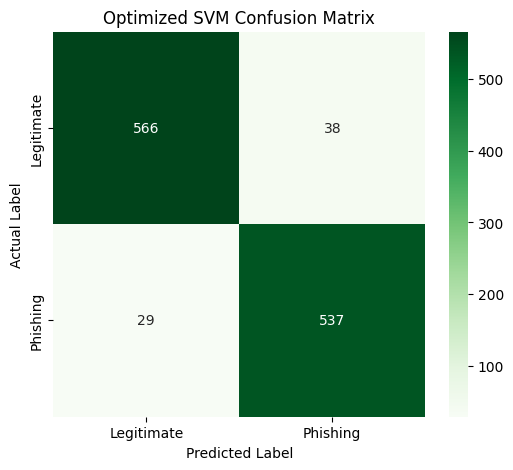

In [ ]:

# optimized svm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


# 2. Create Pipeline (Scaling + SVM)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# 3. Hyperparameter Grid

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.1, 0.01, 0.001, 'scale'],
    'svm__kernel': ['rbf']
}


# 4. GridSearchCV

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'

)


# 5. Train Model

grid.fit(X_train, y_train)


# 6. Best Model
best_svm = grid.best_estimator_

print("\nBest Hyperparameters Found:")
print(grid.best_params_)

# 7. Model Evaluation

svm_pred = best_svm.predict(X_test)

print("\nOptimized SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nOptimized SVM Classification Report:\n")
print(classification_report(y_test, svm_pred))


# 8. Confusion Matrix

svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)
plt.title("Optimized SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


Decision Tree Accuracy: 0.9085470085470085

Decision Tree Classification Report:

              precision    recall  f1-score   support

          -1       0.97      0.85      0.91       604
           1       0.86      0.97      0.91       566

    accuracy                           0.91      1170
   macro avg       0.91      0.91      0.91      1170
weighted avg       0.91      0.91      0.91      1170



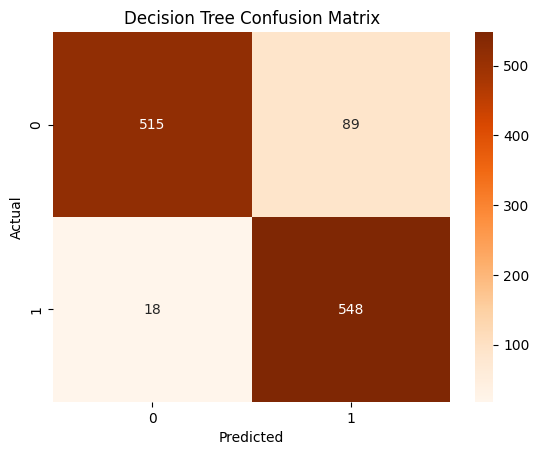

In [ ]:
# DecisionTree
dt = DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, dt_pred))

#Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Gaussian Naive Bayes Accuracy: 0.6547008547008547

Gaussian Naive Bayes Classification Report:

              precision    recall  f1-score   support

          -1       0.60      1.00      0.75       604
           1       0.99      0.29      0.45       566

    accuracy                           0.65      1170
   macro avg       0.80      0.64      0.60      1170
weighted avg       0.79      0.65      0.60      1170



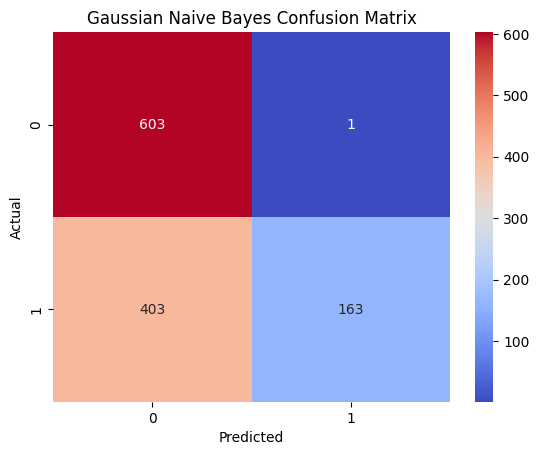

In [ ]:
#Gaussian Naive Bayes

gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)


print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test, gnb_pred))
print("\nGaussian Naive Bayes Classification Report:\n")
print(classification_report(y_test, gnb_pred))

gnb_cm = confusion_matrix(y_test, gnb_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(gnb_cm, annot=True, fmt="d", cmap="coolwarm")
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Logistic Regression Accuracy: 0.9128205128205128

Logistic Regression Classification Report:

              precision    recall  f1-score   support

          -1       0.93      0.90      0.91       604
           1       0.90      0.92      0.91       566

    accuracy                           0.91      1170
   macro avg       0.91      0.91      0.91      1170
weighted avg       0.91      0.91      0.91      1170



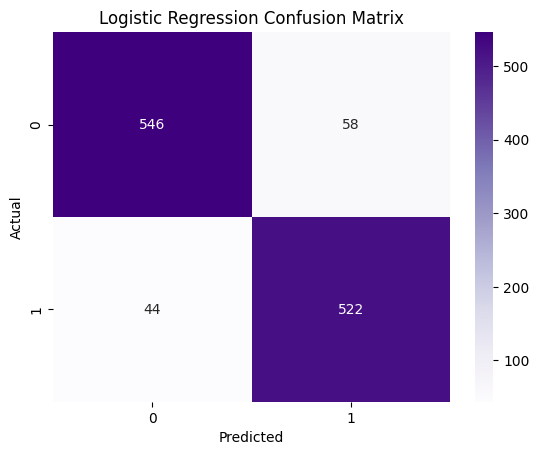

In [ ]:
#Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, lr_pred))

lr_cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Purples")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Gradient Boosting Accuracy: 0.9461538461538461

Gradient Boosting Classification Report:

              precision    recall  f1-score   support

          -1       0.95      0.94      0.95       604
           1       0.94      0.95      0.94       566

    accuracy                           0.95      1170
   macro avg       0.95      0.95      0.95      1170
weighted avg       0.95      0.95      0.95      1170



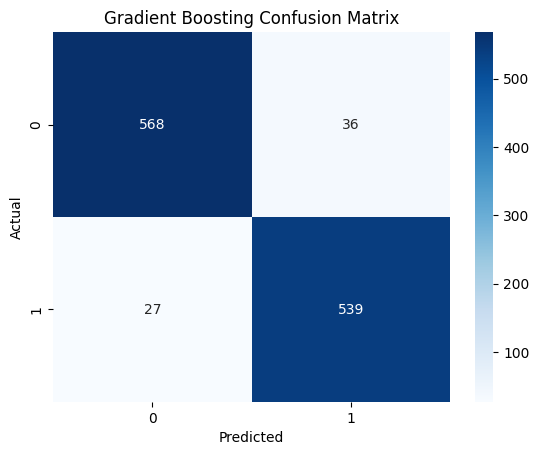

AdaBoost Accuracy: 0.9299145299145299

AdaBoost Classification Report:

              precision    recall  f1-score   support

          -1       0.94      0.92      0.93       604
           1       0.92      0.94      0.93       566

    accuracy                           0.93      1170
   macro avg       0.93      0.93      0.93      1170
weighted avg       0.93      0.93      0.93      1170



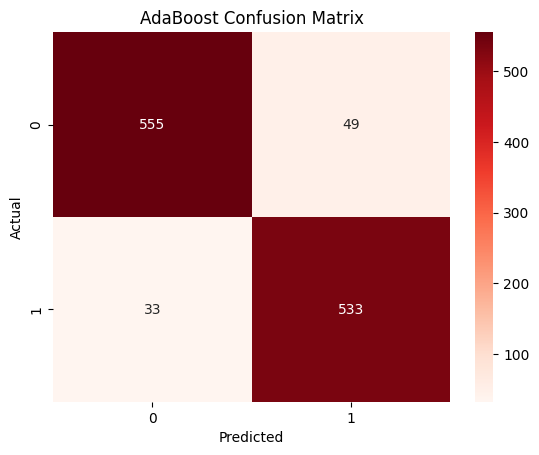

In [ ]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------ Gradient Boosting ------------------ #
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("\nGradient Boosting Classification Report:\n")
print(classification_report(y_test, gb_pred))

gb_cm = confusion_matrix(y_test, gb_pred)

sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------ AdaBoost ------------------ #
ab = AdaBoostClassifier()
ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ab_pred))
print("\nAdaBoost Classification Report:\n")
print(classification_report(y_test, ab_pred))

ab_cm = confusion_matrix(y_test, ab_pred)

sns.heatmap(ab_cm, annot=True, fmt="d", cmap="Reds")
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


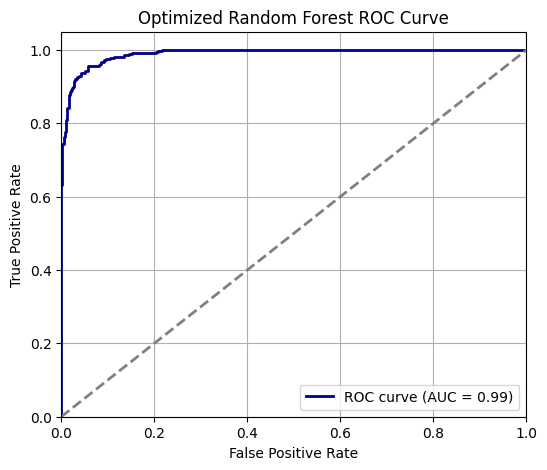

In [ ]:

# 9. ROC AUC Curve for Random Forest


# Get predicted probabilities for the positive class
rf_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC AUC
rf_roc_auc = roc_auc_score(y_test, rf_probs)
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {rf_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


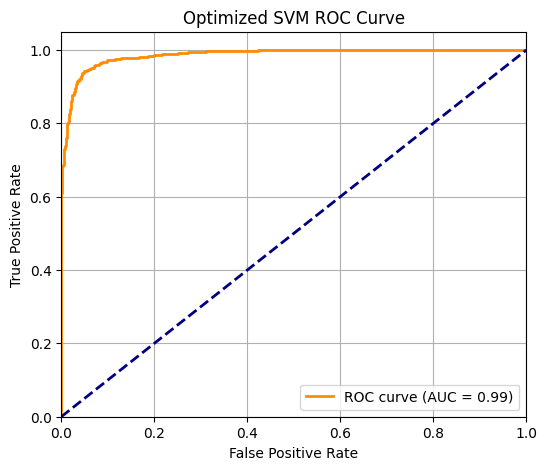

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay


# 9. ROC AUC Curve

# Get decision function scores
svm_scores = best_svm.decision_function(X_test)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, svm_scores)
fpr, tpr, thresholds = roc_curve(y_test, svm_scores)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized SVM ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
